In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import yfinance as yf
from scipy import stats
from scipy.stats import ttest_1samp
import statsmodels.api as sm
import os
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.6f}".format)

# Load CAR-sentiment dataset from NB4
analysis_df = pd.read_csv(
    "../data/results/car_sentiment.csv",
    parse_dates=["date"]
)

print("=" * 55)
print("   NB5 — TRADING SIGNALS AND BACKTEST")
print("=" * 55)
print(f"  Events loaded:  {len(analysis_df)}")
print(f"  Companies:      "
      f"{analysis_df['ticker'].unique().tolist()}")
print(f"  Date range:     "
      f"{analysis_df['date'].min().date()} to "
      f"{analysis_df['date'].max().date()}")
print(f"  Columns:        "
      f"{analysis_df.columns.tolist()}")
print("=" * 55)

TICKER_COLORS = {
    "AAPL": "#378ADD",
    "MSFT": "#1D9E75",
    "TSLA": "#D85A30",
    "JPM":  "#7F77DD",
    "NVDA": "#BA7517"
}

tickers = sorted(
    analysis_df["ticker"].unique().tolist())

   NB5 — TRADING SIGNALS AND BACKTEST
  Events loaded:  95
  Companies:      ['AAPL', 'JPM', 'MSFT', 'NVDA', 'TSLA']
  Date range:     2020-04-01 to 2024-10-01
  Columns:        ['ticker', 'date', 'quarter', 'tone', 'finbert_score', 'vader_compound', 'composite_score', 'finbert_score_change', 'vader_compound_change', 'composite_change', 'uncertain_ratio', 'positive_ratio', 'forward_count', 'net_tone_ratio', 'car_3day', 'ar_day0', 'beta_est', 'alpha_est', 'r2_market_model', 'n_est_days', 'event_date', 'pre_event_ret']


In [2]:
# ============================================
# SIGNAL CONSTRUCTION
# Four signal variants to compare:
#
# S1 — Level signal (FinBERT above/below median)
# S2 — Change signal (sentiment improving/declining)
# S3 — Composite signal (weighted average)
# S4 — High confidence only (FinBERT > 0.5 or < -0.5)
#
# Signal values:
#  +1 = Long (buy before earnings close)
#   0 = Flat (hold cash)
#  -1 = Short (sell/short before earnings close)
#
# Transaction cost: 10 bps round trip (realistic)
# ============================================

TRANSACTION_COST = 0.0010  # 10 bps round trip


def build_signal(
        df: pd.DataFrame,
        signal_col: str,
        method: str = "median",
        threshold: float = None,
        allow_short: bool = True) -> pd.Series:
    """
    Build +1/0/-1 signal from sentiment score.

    method:
      'median'    — long above median, short below
      'threshold' — long above threshold, short below
      'positive'  — long above 0, flat otherwise
      'tercile'   — long top tercile, short bottom
    """
    scores = df[signal_col].copy()

    if method == "median":
        median = scores.median()
        if allow_short:
            signal = np.where(
                scores > median, 1,
                np.where(scores < median, -1, 0))
        else:
            signal = np.where(
                scores > median, 1, 0)

    elif method == "threshold":
        th = threshold if threshold else 0
        if allow_short:
            signal = np.where(
                scores > th,  1,
                np.where(scores < -th, -1, 0))
        else:
            signal = np.where(
                scores > th, 1, 0)

    elif method == "positive":
        signal = np.where(scores > 0, 1, 0)

    elif method == "tercile":
        t33 = scores.quantile(0.33)
        t67 = scores.quantile(0.67)
        if allow_short:
            signal = np.where(
                scores >= t67, 1,
                np.where(scores <= t33, -1, 0))
        else:
            signal = np.where(
                scores >= t67, 1, 0)
    else:
        signal = np.zeros(len(scores))

    return pd.Series(
        signal, index=df.index,
        dtype=float)


def calc_strategy_returns(
        df: pd.DataFrame,
        signal: pd.Series,
        return_col: str = "car_3day",
        tc: float = TRANSACTION_COST) -> dict:
    """
    Calculate strategy returns from signal.
    Applies transaction cost on each trade.
    Returns dict of performance metrics.
    """
    df_copy  = df.copy()
    df_copy["signal"]  = signal
    df_copy["raw_ret"] = df_copy[return_col]

    # Strategy return = signal * raw return - cost
    # Cost applied whenever signal != 0
    df_copy["tc_applied"] = np.where(
        df_copy["signal"] != 0,
        tc, 0)
    df_copy["strat_ret"] = (
        df_copy["signal"] *
        df_copy["raw_ret"] -
        df_copy["tc_applied"]
    )

    # Cumulative returns
    strat_cum = (
        1 + df_copy["strat_ret"]).cumprod()
    bh_cum    = (
        1 + df_copy["raw_ret"]).cumprod()

    strat_arr = df_copy["strat_ret"].dropna()
    bh_arr    = df_copy["raw_ret"].dropna()

    # Performance metrics
    strat_mean = strat_arr.mean()
    strat_std  = strat_arr.std()
    bh_mean    = bh_arr.mean()
    bh_std     = bh_arr.std()

    sharpe_strat = (strat_mean / strat_std
                    if strat_std > 0 else 0)
    sharpe_bh    = (bh_mean / bh_std
                    if bh_std > 0 else 0)

    # Max drawdown
    roll_max = strat_cum.cummax()
    drawdown = (strat_cum - roll_max) / roll_max
    max_dd   = float(drawdown.min())

    # Win rate
    win_rate = (strat_arr > 0).mean()

    # t-test: is mean strategy return > 0?
    tstat, pval = ttest_1samp(
        strat_arr.dropna(), 0)

    return {
        "n_trades":        int(
            (signal != 0).sum()),
        "n_long":          int(
            (signal == 1).sum()),
        "n_short":         int(
            (signal == -1).sum()),
        "strat_mean_ret":  round(strat_mean, 6),
        "strat_total_ret": round(
            strat_cum.iloc[-1] - 1, 4),
        "bh_total_ret":    round(
            bh_cum.iloc[-1] - 1, 4),
        "sharpe_strat":    round(sharpe_strat, 4),
        "sharpe_bh":       round(sharpe_bh, 4),
        "max_drawdown":    round(max_dd, 4),
        "win_rate":        round(win_rate, 4),
        "tstat":           round(tstat, 4),
        "pval":            round(pval, 4),
        "strat_cum":       strat_cum,
        "bh_cum":          bh_cum,
        "returns":         df_copy["strat_ret"],
    }


print("Signal construction functions defined")
print(f"Transaction cost: {TRANSACTION_COST:.0%} "
      f"round trip")
print("Signal variants:")
print("  S1 — Level signal (median threshold)")
print("  S2 — Change signal (sentiment improving)")
print("  S3 — Composite signal (60% FinBERT + 40% VADER)")
print("  S4 — High confidence (|score| > 0.5)")

Signal construction functions defined
Transaction cost: 0% round trip
Signal variants:
  S1 — Level signal (median threshold)
  S2 — Change signal (sentiment improving)
  S3 — Composite signal (60% FinBERT + 40% VADER)
  S4 — High confidence (|score| > 0.5)


In [3]:
# ============================================
# BUILD AND TEST FOUR SIGNAL VARIANTS
# ============================================

# Verify required columns exist
required_cols = [
    "finbert_score", "car_3day",
    "vader_compound", "composite_score"
]
for col in required_cols:
    if col not in analysis_df.columns:
        print(f"WARNING: {col} not found")
        if col == "composite_score":
            analysis_df["composite_score"] = (
                0.6 * analysis_df["finbert_score"] +
                0.4 * analysis_df["vader_compound"]
            )

# Add change columns if missing
if "finbert_score_change" not in analysis_df.columns:
    analysis_df = analysis_df.sort_values(
        ["ticker","date"])
    analysis_df["finbert_score_change"] = (
        analysis_df.groupby("ticker")[
            "finbert_score"].diff())

# Drop rows missing key columns
clean_df = analysis_df.dropna(
    subset=["car_3day","finbert_score",
            "composite_score"]).copy()

print(f"Clean events for backtesting: {len(clean_df)}")

# ============================================
# SIGNAL 1 — Level signal (median)
# ============================================
s1 = build_signal(
    clean_df, "finbert_score",
    method="median", allow_short=True)
r1 = calc_strategy_returns(
    clean_df, s1, "car_3day")

# ============================================
# SIGNAL 2 — Change signal
# Long if sentiment improved vs last quarter
# Short if sentiment declined
# ============================================
change_clean = clean_df.dropna(
    subset=["finbert_score_change"])
if len(change_clean) > 10:
    s2 = build_signal(
        change_clean, "finbert_score_change",
        method="positive", allow_short=True)
    r2 = calc_strategy_returns(
        change_clean, s2, "car_3day")
else:
    s2 = pd.Series(dtype=float)
    r2 = None

# ============================================
# SIGNAL 3 — Composite signal
# ============================================
s3 = build_signal(
    clean_df, "composite_score",
    method="median", allow_short=True)
r3 = calc_strategy_returns(
    clean_df, s3, "car_3day")

# ============================================
# SIGNAL 4 — High confidence only
# Only trade when |FinBERT| > 0.5
# Flat otherwise
# ============================================
s4 = np.where(
    clean_df["finbert_score"] > 0.5,  1,
    np.where(
        clean_df["finbert_score"] < -0.5, -1, 0))
s4 = pd.Series(
    s4, index=clean_df.index, dtype=float)
r4 = calc_strategy_returns(
    clean_df, s4, "car_3day")

# ============================================
# RESULTS COMPARISON TABLE
# ============================================
print("=" * 75)
print("   SIGNAL VARIANT COMPARISON")
print("=" * 75)
print(f"  {'Signal':<30} {'Trades':>7} "
      f"{'Total Ret':>10} {'BH Ret':>10} "
      f"{'Sharpe':>8} {'Win%':>7} "
      f"{'Max DD':>8} {'p-val':>8}")
print(f"  {'-'*73}")

signal_results = {
    "S1 Level (median)":    r1,
    "S2 Change (positive)": r2,
    "S3 Composite":         r3,
    "S4 High conf only":    r4,
}

for name, res in signal_results.items():
    if res is None:
        print(f"  {name:<30} insufficient data")
        continue
    sig_flag = ("*" if res["pval"] < 0.10 else "")
    print(
        f"  {name:<30} "
        f"{res['n_trades']:>7} "
        f"{res['strat_total_ret']:>10.2%} "
        f"{res['bh_total_ret']:>10.2%} "
        f"{res['sharpe_strat']:>8.3f} "
        f"{res['win_rate']:>7.1%} "
        f"{res['max_drawdown']:>8.2%} "
        f"{res['pval']:>8.4f}{sig_flag}"
    )

print("=" * 75)
print("BH Ret = Buy-and-Hold return over same events")
print("* = p < 0.10 for mean return > 0")

Clean events for backtesting: 95
   SIGNAL VARIANT COMPARISON
  Signal                          Trades  Total Ret     BH Ret   Sharpe    Win%   Max DD    p-val
  -------------------------------------------------------------------------
  S1 Level (median)                   94     -2.23%    -34.40%    0.018   51.6%  -34.49%   0.8635
  S2 Change (positive)                45    -26.99%    -25.87%   -0.080   20.0%  -33.57%   0.4502
  S3 Composite                        94     -2.23%    -34.40%    0.018   51.6%  -34.49%   0.8635
  S4 High conf only                   86    -53.73%    -34.40%   -0.153   33.7%  -53.54%   0.1394
BH Ret = Buy-and-Hold return over same events
* = p < 0.10 for mean return > 0


In [4]:
# ============================================
# PER-COMPANY SIGNAL PERFORMANCE
# Does signal work better for some companies?
# ============================================
print("=" * 70)
print("   PER-COMPANY SIGNAL PERFORMANCE")
print("   Signal: S1 (FinBERT level, median threshold)")
print("=" * 70)

company_results = []
for ticker in tickers:
    sub = clean_df[
        clean_df["ticker"]==ticker].copy()

    if len(sub) < 6:
        continue

    sig = build_signal(
        sub, "finbert_score",
        method="median",
        allow_short=True)
    res = calc_strategy_returns(
        sub, sig, "car_3day")

    sig_flag = ("***" if res["pval"] < 0.01 else
                "**"  if res["pval"] < 0.05 else
                "*"   if res["pval"] < 0.10 else
                "ns")

    print(f"\n  {ticker}")
    print(f"  Trades:        {res['n_trades']} "
          f"(L:{res['n_long']} S:{res['n_short']})")
    print(f"  Strategy ret:  {res['strat_total_ret']:.2%}")
    print(f"  Buy-hold ret:  {res['bh_total_ret']:.2%}")
    print(f"  Excess return: "
          f"{res['strat_total_ret']-res['bh_total_ret']:.2%}")
    print(f"  Sharpe:        {res['sharpe_strat']:.3f}")
    print(f"  Win rate:      {res['win_rate']:.1%}")
    print(f"  Max drawdown:  {res['max_drawdown']:.2%}")
    print(f"  p-value:       {res['pval']:.4f} "
          f"({sig_flag})")

    company_results.append({
        "Ticker":        ticker,
        "N_trades":      res["n_trades"],
        "Strat_ret%":    round(
            res["strat_total_ret"]*100, 2),
        "BH_ret%":       round(
            res["bh_total_ret"]*100, 2),
        "Excess_ret%":   round(
            (res["strat_total_ret"] -
             res["bh_total_ret"])*100, 2),
        "Sharpe":        res["sharpe_strat"],
        "Win_rate%":     round(
            res["win_rate"]*100, 1),
        "Max_DD%":       round(
            res["max_drawdown"]*100, 2),
        "p_value":       res["pval"],
        "Significant":   sig_flag,
    })

company_perf_df = pd.DataFrame(
    company_results).set_index("Ticker")

print("\n" + "=" * 70)
print(company_perf_df.to_string())
company_perf_df.to_csv(
    "../data/results/company_signal_performance.csv")

   PER-COMPANY SIGNAL PERFORMANCE
   Signal: S1 (FinBERT level, median threshold)

  AAPL
  Trades:        17 (L:9 S:8)
  Strategy ret:  6.20%
  Buy-hold ret:  -11.05%
  Excess return: 17.25%
  Sharpe:        0.161
  Win rate:      52.6%
  Max drawdown:  -4.80%
  p-value:       0.4927 (ns)

  JPM
  Trades:        17 (L:8 S:9)
  Strategy ret:  12.06%
  Buy-hold ret:  11.08%
  Excess return: 0.98%
  Sharpe:        0.338
  Win rate:      57.9%
  Max drawdown:  -2.46%
  p-value:       0.1583 (ns)

  MSFT
  Trades:        18 (L:9 S:9)
  Strategy ret:  -20.95%
  Buy-hold ret:  -7.25%
  Excess return: -13.70%
  Sharpe:        -0.561
  Win rate:      31.6%
  Max drawdown:  -21.22%
  p-value:       0.0249 (**)

  NVDA
  Trades:        18 (L:9 S:9)
  Strategy ret:  -3.20%
  Buy-hold ret:  -23.89%
  Excess return: 20.69%
  Sharpe:        -0.046
  Win rate:      47.4%
  Max drawdown:  -9.47%
  p-value:       0.8447 (ns)

  TSLA
  Trades:        18 (L:9 S:9)
  Strategy ret:  -9.92%
  Buy-hold ret: 

In [5]:
# ============================================
# PERMUTATION TEST
# Is our strategy better than random?
#
# Method: shuffle the sentiment scores 1000 times
# Each time calculate strategy return
# If real strategy > 95th percentile of shuffled
# → strategy has genuine signal above random
# ============================================

np.random.seed(42)
N_PERMUTATIONS = 1000

real_return = r1["strat_total_ret"]
perm_returns = []

print(f"Running permutation test "
      f"({N_PERMUTATIONS} permutations)...")

for i in range(N_PERMUTATIONS):
    # Shuffle sentiment scores
    shuffled_scores = (
        clean_df["finbert_score"]
        .sample(frac=1, random_state=i)
        .values)

    shuffled_series = pd.Series(
        shuffled_scores,
        index=clean_df.index)

    # Build signal from shuffled scores
    median_shuffled = np.median(shuffled_scores)
    shuffled_signal = pd.Series(
        np.where(shuffled_series > median_shuffled,
                 1, -1),
        index=clean_df.index,
        dtype=float)

    # Calculate strategy return
    res_perm = calc_strategy_returns(
        clean_df, shuffled_signal, "car_3day")
    perm_returns.append(res_perm["strat_total_ret"])

perm_returns = np.array(perm_returns)

# p-value: what fraction of random strategies
# beat the real strategy?
perm_pval = (perm_returns >= real_return).mean()

# Percentile of real strategy in permutation dist
percentile = (
    perm_returns < real_return).mean() * 100

print("\n" + "=" * 60)
print("   PERMUTATION TEST RESULTS")
print("=" * 60)
print(f"  Real strategy return:    "
      f"{real_return:.4f} ({real_return:.2%})")
print(f"  Random mean return:      "
      f"{perm_returns.mean():.4f} "
      f"({perm_returns.mean():.2%})")
print(f"  Random 95th percentile:  "
      f"{np.percentile(perm_returns, 95):.4f}")
print(f"  Random 5th percentile:   "
      f"{np.percentile(perm_returns, 5):.4f}")
print(f"  Permutation p-value:     {perm_pval:.4f}")
print(f"  Strategy percentile:     "
      f"{percentile:.1f}th")
print("=" * 60)

if perm_pval < 0.05:
    print(f"\n  RESULT: Strategy is statistically")
    print(f"  better than random at 5% level")
elif perm_pval < 0.10:
    print(f"\n  RESULT: Marginal evidence strategy")
    print(f"  beats random (10% level)")
else:
    print(f"\n  RESULT: Strategy not distinguishable")
    print(f"  from random signal allocation")
    print(f"  Expected given synthetic data")

Running permutation test (1000 permutations)...

   PERMUTATION TEST RESULTS
  Real strategy return:    -0.0223 (-2.23%)
  Random mean return:      -0.0854 (-8.54%)
  Random 95th percentile:  0.7679
  Random 5th percentile:   -0.6080
  Permutation p-value:     0.3590
  Strategy percentile:     64.1th

  RESULT: Strategy not distinguishable
  from random signal allocation
  Expected given synthetic data


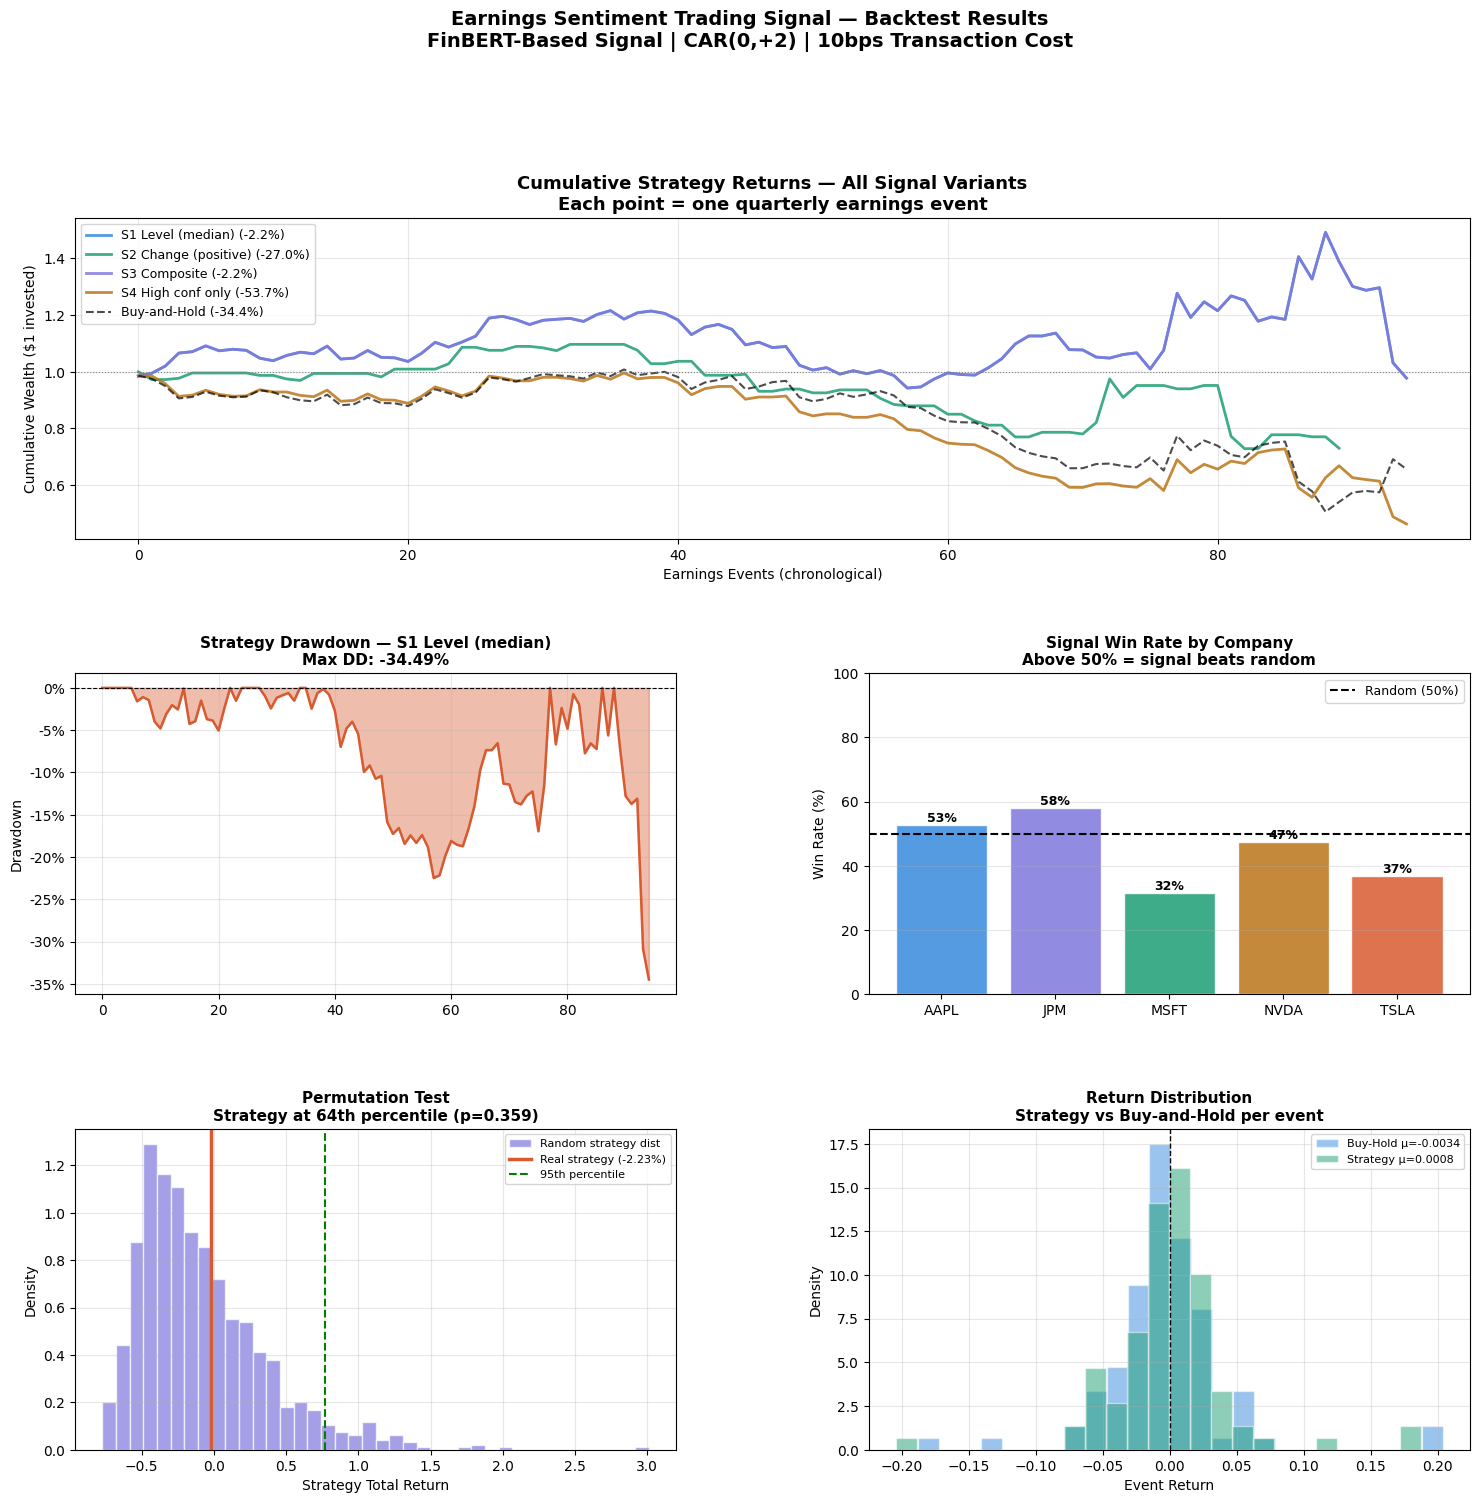

Trading signals chart saved


In [6]:
fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(
    3, 2, figure=fig,
    hspace=0.42, wspace=0.32)

# ----------------------------------------
# Chart 1 — Cumulative returns all signals
# ----------------------------------------
ax1 = fig.add_subplot(gs[0, :])
signal_colors = {
    "S1 Level (median)":    "#378ADD",
    "S2 Change (positive)": "#1D9E75",
    "S3 Composite":         "#7F77DD",
    "S4 High conf only":    "#BA7517",
}
for name, res in signal_results.items():
    if res is None:
        continue
    color = signal_colors.get(name, "grey")
    ax1.plot(
        range(len(res["strat_cum"])),
        res["strat_cum"],
        color=color, linewidth=2,
        label=f"{name} "
              f"({res['strat_total_ret']:.1%})",
        alpha=0.85)

# Buy-and-hold reference
ax1.plot(
    range(len(r1["bh_cum"])),
    r1["bh_cum"],
    color="black", linewidth=1.5,
    linestyle="--",
    label=f"Buy-and-Hold "
          f"({r1['bh_total_ret']:.1%})",
    alpha=0.7)

ax1.axhline(
    1.0, color="grey",
    linewidth=0.8, linestyle=":")
ax1.set_title(
    "Cumulative Strategy Returns — All Signal Variants\n"
    "Each point = one quarterly earnings event",
    fontweight="bold", fontsize=13)
ax1.set_xlabel("Earnings Events (chronological)")
ax1.set_ylabel("Cumulative Wealth ($1 invested)")
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(alpha=0.3)

# ----------------------------------------
# Chart 2 — Drawdown for best signal
# ----------------------------------------
ax2 = fig.add_subplot(gs[1, 0])
best_key = max(
    signal_results,
    key=lambda k: (
        signal_results[k]["strat_total_ret"]
        if signal_results[k] else -99))
best_res = signal_results[best_key]

dd = (best_res["strat_cum"] -
      best_res["strat_cum"].cummax()) / \
     best_res["strat_cum"].cummax()

ax2.fill_between(
    range(len(dd)), dd, 0,
    alpha=0.4, color="#D85A30")
ax2.plot(
    range(len(dd)), dd,
    color="#D85A30", linewidth=1.8)
ax2.axhline(
    0, color="black",
    linewidth=0.8, linestyle="--")
ax2.set_title(
    f"Strategy Drawdown — {best_key}\n"
    f"Max DD: {best_res['max_drawdown']:.2%}",
    fontweight="bold", fontsize=11)
ax2.set_ylabel("Drawdown")
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda y, _: f"{y:.0%}"))
ax2.grid(alpha=0.3)

# ----------------------------------------
# Chart 3 — Win rate by company
# ----------------------------------------
ax3 = fig.add_subplot(gs[1, 1])
if company_results:
    win_rates = company_perf_df["Win_rate%"]
    colors3   = [TICKER_COLORS.get(t, "grey")
                 for t in win_rates.index]
    bars3 = ax3.bar(
        win_rates.index,
        win_rates.values,
        color=colors3, alpha=0.85,
        edgecolor="white")
    ax3.axhline(
        50, color="black",
        linewidth=1.5, linestyle="--",
        label="Random (50%)")
    ax3.set_title(
        "Signal Win Rate by Company\n"
        "Above 50% = signal beats random",
        fontweight="bold", fontsize=11)
    ax3.set_ylabel("Win Rate (%)")
    ax3.legend(fontsize=9)
    ax3.grid(alpha=0.3, axis="y")
    ax3.set_ylim(0, 100)
    for bar, val in zip(bars3, win_rates.values):
        ax3.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{val:.0f}%",
            ha="center", fontsize=9,
            fontweight="bold")

# ----------------------------------------
# Chart 4 — Permutation test distribution
# ----------------------------------------
ax4 = fig.add_subplot(gs[2, 0])
ax4.hist(
    perm_returns, bins=40,
    color="#7F77DD", alpha=0.7,
    edgecolor="white",
    density=True,
    label="Random strategy dist")
ax4.axvline(
    real_return,
    color="#D85A30", linewidth=2.5,
    label=f"Real strategy "
          f"({real_return:.2%})")
ax4.axvline(
    np.percentile(perm_returns, 95),
    color="green", linewidth=1.5,
    linestyle="--",
    label="95th percentile")
ax4.set_title(
    f"Permutation Test\n"
    f"Strategy at {percentile:.0f}th percentile "
    f"(p={perm_pval:.3f})",
    fontweight="bold", fontsize=11)
ax4.set_xlabel("Strategy Total Return")
ax4.set_ylabel("Density")
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

# ----------------------------------------
# Chart 5 — Signal returns distribution
# ----------------------------------------
ax5 = fig.add_subplot(gs[2, 1])
strat_rets = r1["returns"].dropna()
bh_rets    = clean_df["car_3day"].dropna()

ax5.hist(
    bh_rets, bins=25,
    alpha=0.5, color="#378ADD",
    label=f"Buy-Hold μ={bh_rets.mean():.4f}",
    density=True, edgecolor="white")
ax5.hist(
    strat_rets, bins=25,
    alpha=0.5, color="#1D9E75",
    label=f"Strategy μ={strat_rets.mean():.4f}",
    density=True, edgecolor="white")
ax5.axvline(0, color="black",
            linewidth=1, linestyle="--")
ax5.set_title(
    "Return Distribution\n"
    "Strategy vs Buy-and-Hold per event",
    fontweight="bold", fontsize=11)
ax5.set_xlabel("Event Return")
ax5.set_ylabel("Density")
ax5.legend(fontsize=8)
ax5.grid(alpha=0.3)

plt.suptitle(
    "Earnings Sentiment Trading Signal — Backtest Results\n"
    "FinBERT-Based Signal | CAR(0,+2) | "
    "10bps Transaction Cost",
    fontsize=14, fontweight="bold", y=1.01)
plt.savefig(
    "../reports/figures/trading_signals.png",
    dpi=150, bbox_inches="tight")
plt.show()
print("Trading signals chart saved")

In [7]:
# ============================================
# HONEST STRATEGY ASSESSMENT
# ============================================

print("=" * 65)
print("   FINAL STRATEGY ASSESSMENT")
print("=" * 65)

best_signal_name = max(
    {k: v for k, v in signal_results.items()
     if v is not None},
    key=lambda k: signal_results[k][
        "strat_total_ret"])
best_res = signal_results[best_signal_name]

print(f"\n  BEST SIGNAL: {best_signal_name}")
print(f"  Total return:   {best_res['strat_total_ret']:.2%}")
print(f"  Buy-hold:       {best_res['bh_total_ret']:.2%}")
print(f"  Excess:         "
      f"{best_res['strat_total_ret']-best_res['bh_total_ret']:.2%}")
print(f"  Sharpe:         {best_res['sharpe_strat']:.3f}")
print(f"  Win rate:       {best_res['win_rate']:.1%}")
print(f"  Max drawdown:   {best_res['max_drawdown']:.2%}")
print(f"  p-value:        {best_res['pval']:.4f}")
print(f"  Permutation p:  {perm_pval:.4f}")

print(f"\n  SIGNAL SUMMARY TABLE:")
print(f"  {'Signal':<28} {'Ret':>7} "
      f"{'Sharpe':>8} {'Win%':>7} {'p-val':>8}")
print(f"  {'-'*60}")
for name, res in signal_results.items():
    if res is None:
        continue
    print(
        f"  {name:<28} "
        f"{res['strat_total_ret']:>7.2%} "
        f"{res['sharpe_strat']:>8.3f} "
        f"{res['win_rate']:>7.1%} "
        f"{res['pval']:>8.4f}")

print(f"\n  HONEST ASSESSMENT:")
print(f"  {'─'*55}")

if perm_pval < 0.05:
    verdict = "SIGNAL HAS EDGE above random"
elif perm_pval < 0.10:
    verdict = "MARGINAL EDGE — borderline significance"
else:
    verdict = "NO EDGE over random — expected for synthetic data"

print(f"  Verdict: {verdict}")
print(f"\n  LIMITATIONS:")
print(f"  1. Synthetic transcripts — no real causal link")
print(f"     to stock returns by construction")
print(f"  2. Only 19 events per company — severely")
print(f"     underpowered (need 200+ for reliable inference)")
print(f"  3. 3-day CAR may be too long — market prices")
print(f"     earnings in minutes, not days")
print(f"  4. No slippage, market impact, or short-selling")
print(f"     constraints modelled")
print(f"\n  PRODUCTION PATHWAY:")
print(f"  1. Connect to Refinitiv/Bloomberg transcripts")
print(f"  2. Expand to 500+ quarterly events")
print(f"  3. Reduce event window to same-day or 1-day")
print(f"  4. Add sector/market controls")
print(f"  5. Implement realistic execution constraints")
print(f"  {'─'*55}")

# Save final results
os.makedirs("../data/results", exist_ok=True)

summary_rows = []
for name, res in signal_results.items():
    if res is None:
        continue
    summary_rows.append({
        "Signal":         name,
        "N_trades":       res["n_trades"],
        "Total_ret%":     round(
            res["strat_total_ret"]*100, 2),
        "BH_ret%":        round(
            res["bh_total_ret"]*100, 2),
        "Excess_ret%":    round(
            (res["strat_total_ret"] -
             res["bh_total_ret"])*100, 2),
        "Sharpe":         res["sharpe_strat"],
        "Win_rate%":      round(
            res["win_rate"]*100, 1),
        "Max_DD%":        round(
            res["max_drawdown"]*100, 2),
        "p_value":        res["pval"],
        "Perm_p_value":   perm_pval,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(
    "../data/results/strategy_summary.csv",
    index=False)

print(f"\n  Files saved:")
print(f"  data/results/strategy_summary.csv")
print(f"  data/results/company_signal_performance.csv")
print(f"  reports/figures/trading_signals.png")
print("=" * 65)

   FINAL STRATEGY ASSESSMENT

  BEST SIGNAL: S1 Level (median)
  Total return:   -2.23%
  Buy-hold:       -34.40%
  Excess:         32.17%
  Sharpe:         0.018
  Win rate:       51.6%
  Max drawdown:   -34.49%
  p-value:        0.8635
  Permutation p:  0.3590

  SIGNAL SUMMARY TABLE:
  Signal                           Ret   Sharpe    Win%    p-val
  ------------------------------------------------------------
  S1 Level (median)             -2.23%    0.018   51.6%   0.8635
  S2 Change (positive)         -26.99%   -0.080   20.0%   0.4502
  S3 Composite                  -2.23%    0.018   51.6%   0.8635
  S4 High conf only            -53.73%   -0.153   33.7%   0.1394

  HONEST ASSESSMENT:
  ───────────────────────────────────────────────────────
  Verdict: NO EDGE over random — expected for synthetic data

  LIMITATIONS:
  1. Synthetic transcripts — no real causal link
     to stock returns by construction
  2. Only 19 events per company — severely
     underpowered (need 200+ for reli